# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402117
- 姓名：林雨桐
- GitHub 仓库链接：
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告以福州市11856条二手房房源数据为研究对象，围绕房源空间分布、价格水平、区域差异以及房屋面积、房龄等因素与房价之间的关系展开分析。研究首先利用 Python 对原始数据进行缺失值识别、重复值检验、异常值排查、字段清洗和数据类型转换，以保证数据质量；随后采用描述性统计、分组汇总、相关性分析等方法，对不同区域和不同房源特征下的价格表现进行比较，并结合柱状图、直方图、箱线图、散点图等可视化方式呈现分析结果。结果显示，福州市二手房房源分布存在明显区域差异，晋安区、仓山区等区域房源数量较多；房价整体呈右偏分布，中等价位房源占比较高，同时存在少量高价房源；不同区域之间房价差异较为显著，鼓楼区、台江区等中心城区价格水平相对较高；房屋面积与总价之间具有较明显的正相关关系，房龄对房价也存在一定影响，但其作用程度相对有限。总体来看，区位条件仍是影响福州市二手房价格的重要因素，本报告的分析结果可为购房者判断房源价格合理性、理解区域市场特征以及开展城市住房市场数据分析提供参考。


## 2. 数据读取与分析目标



### 1. 数据来源
本次分析所使用的数据为“二手房房源数据（ershoufang_list.csv）”，数据来源于房产信息平台的房源采集结果，包含福州二手房交易相关信息，用于分析房地产市场的价格特征与空间分布情况。

### 2. 数据字段含义说明
该数据主要包含以下字段：

- **城市 / 市区**：表示房源所在的城市及具体行政区域；
- **标题**：房源的简要描述信息；
- **户型**：如“3室2厅1卫”，表示房屋结构；
- **面积 / 面积数值**：房屋建筑面积（㎡）及其数值化结果；
- **方位**：房屋朝向信息；
- **楼层**：所在楼层及总楼层情况；
- **时间**：房屋建造或挂牌时间；
- **所属小区 / 区域**：房源所属小区及地理区域；
- **总价 / 总价数值**：房屋总价格（万元）；
- **均价 / 均价数值**：单位面积价格（元/㎡）；
- **房龄**：房屋建成年限或使用年限；
- **房源链接**：对应房源的网页链接。


### 3. 分析目标
本次数据分析主要围绕以下几个问题展开：

1. 不同市区的二手房数量分布是否存在明显差异？
2. 不同区域的房价（总价与均价）是否存在显著差异？
3. 房屋面积、户型与房价之间是否存在关系？
4. 房龄、楼层等因素是否会影响房价水平？
5. 二手房市场整体价格分布呈现怎样的结构特征？



### 4. 分析意义
通过以上分析，可以帮助理解福州（或样本城市）二手房市场的基本结构特征，为后续房价预测、区域对比及市场分析提供数据支持。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [3]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

请展示数据规模、字段名、数据类型、前几行样例，并用文字说明你对数据的初步理解。

### 1. 数据规模

数据集包含11856条房源记录，共18个字段，说明数据规模较大，可以支持较稳定的统计分析。

In [4]:
# 数据规模
df.shape

(11856, 18)

### 2. 字段名称与数据类型

数据包含房源基本信息字段（如市区、户型、楼层等）以及价格相关字段（如总价、均价）。

其中：
- object类型字段主要为文本信息（如户型、楼层）
- 数值字段包括面积数值、总价数值、均价数值等

In [5]:
# 字段与数据类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


### 3. 数据样例

通过查看前10行数据，可以初步了解数据的结构和内容格式，例如户型表达方式、楼层信息、价格字段等。

In [6]:
df.head(10)

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内
5,6,fuzhou,晋安,五国贸保利和颂锦原 产权清晰 刚需小三居 购物方便 南北通透,3 室 2 厅 2 卫,89㎡,89.0,南北,高层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4591191006796...,193万,193.0,21686元/㎡,21686.0,2年内
6,7,fuzhou,鼓楼,次新小区 文庭雅居 电梯房 南北通透 交通便利,2 室 1 厅 1 卫,62㎡,62.0,南北,低层(共16层),2024年建造,文庭雅居,鼓楼 东街 白马北路,https://fz.anjuke.com/prop/view/S4160547231570...,196万,196.0,31613元/㎡,31613.0,2年内
7,8,fuzhou,晋安,中海 号院B区 交通便利 商圈成熟 次新房 近地铁 小三房,3 室 2 厅 2 卫,99㎡,99.0,南,低层(共18层),2024年建造,中海叁号院B区,晋安 前横路 鱼山路3号,https://fz.anjuke.com/prop/view/S4598334305983...,299万,299.0,30203元/㎡,30203.0,2年内
8,9,fuzhou,台江,榕发望熙雅筑A区 出行方便 医疗配套成熟 近地铁 商圈成熟,2 室 2 厅 1 卫,75㎡,75.0,南北,低层(共34层),2024年建造,榕发望熙雅筑A区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4548445239254...,160万,160.0,21334元/㎡,21334.0,2年内
9,10,fuzhou,台江,宝龙旁宁 化地铁口 2023年人车分离安商社区 70平 两房,2 室 1 厅 1 卫,69㎡,69.0,南北,中层(共27层),2024年建造,春江茗郡,台江 万宝 白马南路289号,https://fz.anjuke.com/prop/view/S3812446186646...,145万,145.0,21015元/㎡,21015.0,2年内


### 4. 描述性统计

从数值字段的统计结果可以观察到面积、总价和均价的分布范围较广，说明不同区域和不同房源之间价格差异明显，可能存在高端房源或异常值。

In [7]:
# 描述性统计
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3887431979344...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


## 4. 数据质量检查

请检查缺失值、重复值、异常值、格式不统一等问题，并说明你的发现。

### 1. 缺失值检查

通过检查各字段的缺失值情况，可以判断数据是否存在信息不完整的问题，从而决定后续是否需要删除或填补。

In [8]:
# 缺失值检查
df.isna().sum()

id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64

从缺失值统计结果可以看出，除价格相关字段（总价、总价数值、均价、均价数值）外，其余字段均无缺失值。

这些缺失值数量较少，占整体数据比例很低，可能来源于部分房源信息未完整采集或爬取失败。在后续分析中，可以选择在涉及价格分析时剔除缺失记录，但不会对整体分析结果造成明显影响。

### 2. 重复值检查

重复数据可能会导致统计结果偏差，因此需要检查是否存在重复记录。

In [9]:
# 重复值检查
df.duplicated().sum()

np.int64(0)

通过重复值检查结果可以看出，数据中不存在重复记录（重复值数量为0），说明数据在采集过程中较为规范，每条房源记录均具有唯一性，因此可以直接用于后续分析，无需进行去重处理。

### 3. 异常值初步检查

通过对面积、总价和均价等数值字段进行描述性统计，可以初步判断是否存在异常值或极端值。

In [10]:
df[['面积数值', '总价数值', '均价数值']].describe()

,面积数值,总价数值,均价数值
count,11856.000000,11830.000000,11830.00000
mean,97.888336,190.761657,19235.60093
std,25.924588,111.174039,6925.94972
min,18.000000,16.800000,2169.00000
25%,84.730000,130.000000,15298.25000
50%,93.000000,173.000000,18325.50000
75%,113.010000,225.000000,22268.50000
max,500.000000,3180.000000,92968.00000


### 异常值分析

通过对面积、总价和均价进行描述性统计可以发现，数据分布范围较广。

面积范围为18㎡至500㎡，覆盖小户型到大平层或别墅类型，属于正常房地产结构差异。

总价从16.8万元到3180万元，均价从2169元/㎡到92968元/㎡，说明数据中既包含低价房源，也包含高端房源。

虽然最大值与均值存在一定差距，但结合房地产市场特性，这些“极端值”更可能代表真实的市场分层，而非数据错误。因此本分析不对异常值进行强制剔除，而是在后续分析中通过分布图进一步观察其影响。

## 5. 数据清洗与字段转换



In [11]:
# 建议先复制一份数据，避免直接破坏原始数据
data = df.copy()
data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


In [13]:
data.columns = data.columns.str.strip()
data['面积_㎡'] = data['面积'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
data['总价_万元'] = data['总价'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
data['均价_元㎡'] = data['均价'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
data['建造年份'] = data['时间'].astype(str).str.extract(r'(\d{4})').astype(float)
data['房龄'] = 2026 - data['建造年份']
data['楼层类型'] = data['楼层'].astype(str).str.extract(r'(低层|中层|高层)')
data['总楼层'] = data['楼层'].astype(str).str.extract(r'共(\d+)层').astype(float)
data['室'] = data['户型'].astype(str).str.extract(r'(\d+)\s*室').astype(float)
data['厅'] = data['户型'].astype(str).str.extract(r'(\d+)\s*厅').astype(float)
data['卫'] = data['户型'].astype(str).str.extract(r'(\d+)\s*卫').astype(float)
data[['面积_㎡','总价_万元','均价_元㎡','房龄','室','厅','卫']].head()

,面积_㎡,总价_万元,均价_元㎡,房龄,室,厅,卫
0,103.0,199.0,19321.0,1.0,3.0,2.0,2.0
1,83.0,181.0,21808.0,1.0,3.0,2.0,2.0
2,90.0,159.0,17667.0,2.0,3.0,2.0,1.0
3,90.0,300.0,33334.0,1.0,3.0,2.0,1.0
4,107.0,330.0,30842.0,2.0,3.0,2.0,2.0


## 数据清洗与字段转换说明

本部分对原始数据中的关键字段进行了清洗与结构化转换，主要目的是将非结构化的文本数据转换为可用于统计分析的数值型数据。

具体处理包括：

1. **面积字段处理**
   从“103㎡”等文本中提取数值部分，将面积统一转换为浮点型变量，便于后续统计计算。

2. **总价字段处理**
   从“199万”等文本中提取数值，转换为以“万元”为单位的数值变量，使价格数据标准化。

3. **均价字段处理**
   从“19321元/㎡”等文本中提取数值部分，统一转换为数值型变量，用于不同区域价格对比分析。

4. **时间字段处理**
   从建造时间中提取年份，并基于当前年份（2026年）计算房龄，以反映房屋使用年限。

5. **楼层字段拆分**
   将“低层(共32层)”等信息拆分为“楼层类型”和“总楼层”，用于分析楼层结构对房价的影响。

6. **户型字段拆分**
   将“3室2厅1卫”等结构拆分为“室、厅、卫”三个独立变量，用于分析户型结构与房价关系。

通过上述处理，原始文本型数据被转换为结构化数值数据，为后续统计分析与可视化提供了可靠的数据基础。

## 6. 描述性统计分析

请使用 `pandas` / `numpy` 完成筛选、排序、分组、聚合、统计描述、透视表或交叉分析，并解释结果含义。

### 6.1 高价房源筛选

In [14]:
high_price = data[data['总价_万元'] > 200]
high_price.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄,面积_㎡,总价_万元,均价_元㎡,建造年份,楼层类型,总楼层,室,厅,卫
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,1.0,90.0,300.0,33334.0,2025.0,低层,7.0,3.0,2.0,1.0
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2.0,107.0,330.0,30842.0,2024.0,低层,18.0,3.0,2.0,2.0
7,8,fuzhou,晋安,中海 号院B区 交通便利 商圈成熟 次新房 近地铁 小三房,3 室 2 厅 2 卫,99㎡,99.0,南,低层(共18层),2024年建造,中海叁号院B区,晋安 前横路 鱼山路3号,https://fz.anjuke.com/prop/view/S4598334305983...,299万,299.0,30203元/㎡,30203.0,2.0,99.0,299.0,30203.0,2024.0,低层,18.0,3.0,2.0,2.0
15,16,fuzhou,仓山,海月江南价格可以谈 正规商品房 精装可拎包入住 电梯房,3 室 2 厅 2 卫,97㎡,97.0,南北,中层(共10层),2024年建造,海月江南,仓山 南江滨西大道 北浦巷2号,https://fz.anjuke.com/prop/view/S4125960806129...,230万,230.0,23712元/㎡,23712.0,2.0,97.0,230.0,23712.0,2024.0,中层,10.0,3.0,2.0,2.0
17,18,fuzhou,台江,万宝商圈，望熙雅筑B区，电梯中层， 位置，南北通透，万象城,3 室 2 厅 2 卫,105㎡,105.0,南北,中层(共31层),2026年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4598346376125...,235万,235.0,22381元/㎡,22381.0,0.0,105.0,235.0,22381.0,2026.0,中层,31.0,3.0,2.0,2.0


通过筛选总价大于200万元的房源，可以观察高价房源的基本情况，用于分析高端房源分布特征。

### 6.2 均价排序分析（前10）

In [ ]:
data.sort_values(by='均价_元㎡', ascending=False).head(10)

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄,面积_㎡,总价_万元,均价_元㎡,建造年份,楼层类型,总楼层,室,厅,卫
2446,2447,fuzhou,晋安,全景晋安湖公园一梯一户改善大平层精装交付豪宅视野开阔,5 室 2 厅 3 卫,234.49㎡,234.49,西南,中层(共20层),2024年建造,建发朗云一区,晋安 东二环 茶香路18号,https://fz.anjuke.com/prop/view/S3958329117568...,2180万,2180.0,92968元/㎡,92968.0,2.0,234.49,2180.0,92968.0,2024.0,中层,20.0,5.0,2.0,3.0
2418,2419,fuzhou,晋安,东泰禾 建发朗云一区五房2000万,5 室 2 厅 3 卫,234.49㎡,234.49,东南,高层(共20层),2024年建造,建发朗云一区,晋安 东二环 茶香路18号,https://fz.anjuke.com/prop/view/S3974064937245...,2000万,2000.0,85292元/㎡,85292.0,2.0,234.49,2000.0,85292.0,2024.0,高层,20.0,5.0,2.0,3.0
2440,2441,fuzhou,晋安,东泰禾 建发朗云一区五房1980万,5 室 2 厅 4 卫,234.49㎡,234.49,东南,中层(共20层),2024年建造,建发朗云一区,晋安 东二环 茶香路18号,https://fz.anjuke.com/prop/view/S4434232123106...,1980万,1980.0,84439元/㎡,84439.0,2.0,234.49,1980.0,84439.0,2024.0,中层,20.0,5.0,2.0,4.0
2449,2450,fuzhou,晋安,晋安区 建发朗云一区 五房 价格有惊喜,5 室 2 厅 4 卫,234.49㎡,234.49,西南,低层(共20层),2024年建造,建发朗云一区,晋安 东二环 茶香路18号,https://fz.anjuke.com/prop/view/S4112496760351...,1780万,1780.0,75910元/㎡,75910.0,2.0,234.49,1780.0,75910.0,2024.0,低层,20.0,5.0,2.0,4.0
2448,2449,fuzhou,晋安,全景晋安湖公园端头大四房一梯一户大平层建发朗云一区,4 室 2 厅 3 卫,204.99㎡,204.99,西南,高层(共19层),2024年建造,建发朗云一区,晋安 东二环 茶香路18号,https://fz.anjuke.com/prop/view/S3931684588135...,1545万,1545.0,75370元/㎡,75370.0,2.0,204.99,1545.0,75370.0,2024.0,高层,19.0,4.0,2.0,3.0
1960,1961,fuzhou,晋安,全景晋安湖公园 两梯两户 端头四房 建发朗云一区 豪宅标配,4 室 2 厅 3 卫,204.99㎡,204.99,南北,中层(共19层),2024年建造,建发朗云一区,晋安 东二环 茶香路18号,https://fz.anjuke.com/prop/view/S4422036400954...,1460万,1460.0,71223元/㎡,71223.0,2.0,204.99,1460.0,71223.0,2024.0,中层,19.0,4.0,2.0,3.0
2472,2473,fuzhou,晋安,东泰禾 建发朗云二区四房1250万,4 室 2 厅 3 卫,180.73㎡,180.73,东南,高层(共24层),2024年建造,建发朗云二区,晋安 东二环 茶香路28号,https://fz.anjuke.com/prop/view/S4107129258368...,1250万,1250.0,69164元/㎡,69164.0,2.0,180.73,1250.0,69164.0,2024.0,高层,24.0,4.0,2.0,3.0
2625,2626,fuzhou,晋安,东泰禾 金府大院 东区顶奢 75 物业,5 室 3 厅 4 卫,258.63㎡,258.63,南北,中层(共30层),2025年建造,泰禾金府大院,晋安 东二环 竹屿路,https://fz.anjuke.com/prop/view/S4622125427123...,1750万,1750.0,67665元/㎡,67665.0,1.0,258.63,1750.0,67665.0,2025.0,中层,30.0,5.0,3.0,4.0
2415,2416,fuzhou,晋安,东泰禾 建发朗云二区四房1200万,4 室 2 厅 3 卫,180.73㎡,180.73,东南,低层(共24层),2024年建造,建发朗云二区,晋安 东二环 茶香路28号,https://fz.anjuke.com/prop/view/S3945458495482...,1200万,1200.0,66398元/㎡,66398.0,2.0,180.73,1200.0,66398.0,2024.0,低层,24.0,4.0,2.0,3.0
2416,2417,fuzhou,晋安,东泰禾 建发朗云二区四房1200万,4 室 2 厅 3 卫,180.73㎡,180.73,西南,低层(共24层),2024年建造,建发朗云二区,晋安 东二环 茶香路28号,https://fz.anjuke.com/prop/view/S3945458523089...,1200万,1200.0,66398元/㎡,66398.0,2.0,180.73,1200.0,66398.0,2024.0,低层,24.0,4.0,2.0,3.0


### 6.3 市区房价分组统计

In [ ]:
city_stats = data.groupby('市区')['总价_万元'].agg(
    ['count', 'mean', 'median']
).sort_values(by='mean', ascending=False)

city_stats

,count,mean,median
市区,,,
鼓楼,1239,220.880952,195.0
台江,906,213.042715,175.0
晋安,4346,208.577589,187.0
仓山,3926,180.642053,173.0
马尾,169,145.867456,128.0
连江,176,142.875000,147.5
福清,219,141.106849,138.0
长乐,106,131.086792,126.0
平潭,59,128.254237,128.0


不同市区的房价存在明显差异。通过均值和中位数可以看出，部分核心区域房价明显高于其他区域，同时房源数量也存在集中趋势。

### 6.4 户型房价分析

In [ ]:
room_stats = data.groupby('室')['总价_万元'].agg(
    ['count', 'mean', 'median']
).sort_values(by='mean', ascending=False)

room_stats

,count,mean,median
室,,,
8.0,2,2465.000000,2465.0
7.0,5,716.200000,510.0
5.0,85,423.869412,275.0
6.0,19,377.210526,300.0
4.0,2288,269.050699,240.0
3.0,7183,180.352791,175.0
2.0,1945,136.303342,131.0
1.0,303,95.153135,85.0


不同户型之间的房价存在差异，通常户型较大的房源总价更高，但样本数量也会影响统计稳定性。

### 6.5 描述性统计分析


In [ ]:
data[['面积_㎡', '总价_万元', '均价_元㎡', '房龄']].describe()

,面积_㎡,总价_万元,均价_元㎡,房龄
count,11856.000000,11830.000000,11830.00000,11856.000000
mean,97.888336,190.761657,19235.60093,8.004049
std,25.924588,111.174039,6925.94972,7.712133
min,18.000000,16.800000,2169.00000,0.000000
25%,84.730000,130.000000,15298.25000,2.000000
50%,93.000000,173.000000,18325.50000,5.000000
75%,113.010000,225.000000,22268.50000,10.000000
max,500.000000,3180.000000,92968.00000,41.000000


从描述性统计结果可以看出，房价、面积等变量分布范围较广，说明数据中存在不同层级的房源结构。

### 6.6 透视表分析（市区 × 房龄）

In [ ]:
pivot = pd.pivot_table(
    data,
    values='均价_元㎡',
    index='市区',
    columns='房龄',
    aggfunc='median'
)

pivot

房龄,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,36.0,38.0,41.0
市区,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
仓山,21992.5,19221.0,15239.5,17297.0,18013.0,18170.0,18082.0,18224.5,17097.0,15504.5,17755.0,17524.5,18233.0,18031.5,17544.5,18573.0,17311.5,20010.5,19048.0,18583.0,16772.5,17183.0,17324.5,17461.0,18342.0,16921.0,20487.0,17942.0,18116.0,19214.5,23834.0,17327.0,31172.0,NaN,18047.0,NaN,21025.0,20412.0,NaN
台江,18000.0,19117.0,21659.0,20368.5,21786.0,20315.0,19606.5,20000.0,23317.5,23739.0,18051.0,16500.0,23801.0,20029.0,28569.0,27929.0,23971.0,17266.0,18845.5,19706.5,17408.0,18572.0,17674.5,17679.0,17183.5,16098.0,15902.0,16240.0,15545.0,15736.5,15546.0,14052.5,NaN,NaN,NaN,NaN,NaN,16842.0,NaN
平潭,12883.0,10960.0,11449.0,12964.0,8403.5,NaN,6091.0,9341.0,7473.0,NaN,6990.0,10494.0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
晋安,14944.0,21012.0,21574.0,20400.0,21343.5,19352.0,19480.5,21908.0,19347.0,19917.0,21822.0,18536.0,19422.0,18226.0,18410.5,15982.5,16974.0,18499.0,16681.0,17675.5,17294.0,17498.5,16831.5,16258.0,16171.0,16026.0,18214.0,15384.0,17097.0,14581.0,18305.5,16922.0,NaN,NaN,17334.0,NaN,17244.5,NaN,NaN
永泰,NaN,7286.0,7917.0,NaN,7186.0,NaN,NaN,NaN,NaN,6105.0,4572.0,5552.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
福清,NaN,7552.0,9520.0,8715.0,16000.0,15711.0,15498.0,13642.5,12522.0,12700.0,7311.0,NaN,NaN,7094.0,NaN,NaN,11755.0,NaN,6577.0,10803.0,NaN,7550.0,NaN,NaN,8003.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
罗源,NaN,NaN,5322.0,NaN,NaN,NaN,NaN,3978.0,5164.0,4810.0,2942.0,5230.0,5103.0,4573.0,NaN,NaN,NaN,2810.0,NaN,NaN,NaN,NaN,NaN,NaN,4720.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
连江,13033.0,9270.0,13182.0,15054.0,12607.0,15260.0,15487.0,15794.0,14795.0,13727.5,11708.0,10166.0,NaN,7382.5,NaN,8925.0,11131.5,8560.0,NaN,NaN,NaN,8321.0,NaN,NaN,6000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
长乐,8328.5,9905.0,11370.0,9342.5,12124.0,8912.0,15527.5,14226.5,15346.0,15951.0,15830.5,7593.0,NaN,NaN,NaN,NaN,10382.0,NaN,12367.0,18877.0,NaN,6032.0,10164.0,5537.5,NaN,NaN,6602.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


通过透视表可以观察不同市区在不同房龄条件下的均价变化情况，体现出房龄与区域共同影响房价的特征。

### 6.7 楼层影响分析

In [ ]:
floor_stats = pd.pivot_table(
    data,
    values='均价_元㎡',
    index='楼层类型',
    aggfunc='mean'
)

floor_stats

,均价_元㎡
楼层类型,
中层,19369.293229
低层,18935.780369
高层,19251.169376


不同楼层类型之间的均价差异较小，说明楼层对房价的影响相对有限，区域因素可能起主导作用。

## 小结

通过筛选、排序、分组统计、透视表等方法可以发现：

1. 不同市区之间存在明显房价差异；
2. 高价房源集中在部分区域；
3. 户型对总价有一定影响；
4. 楼层因素影响相对较弱；
5. 房价受到区域与房龄共同作用。

整体来看，福州二手房市场呈现明显的区域分层和价格梯度结构。

## 7. 可视化分析

请至少绘制 4 张有效图表。每张图都应服务于一个明确的分析问题，并注意图片大小、文字、标题、坐标轴标签、图例和整体排版。

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 高级风格设置 =====
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 120

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文
plt.rcParams['axes.unicode_minus'] = False

### 图表 1：不同市区二手房房源数量分布

C:\Users\swrx\AppData\Local\Temp\ipykernel_22224\1151254581.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


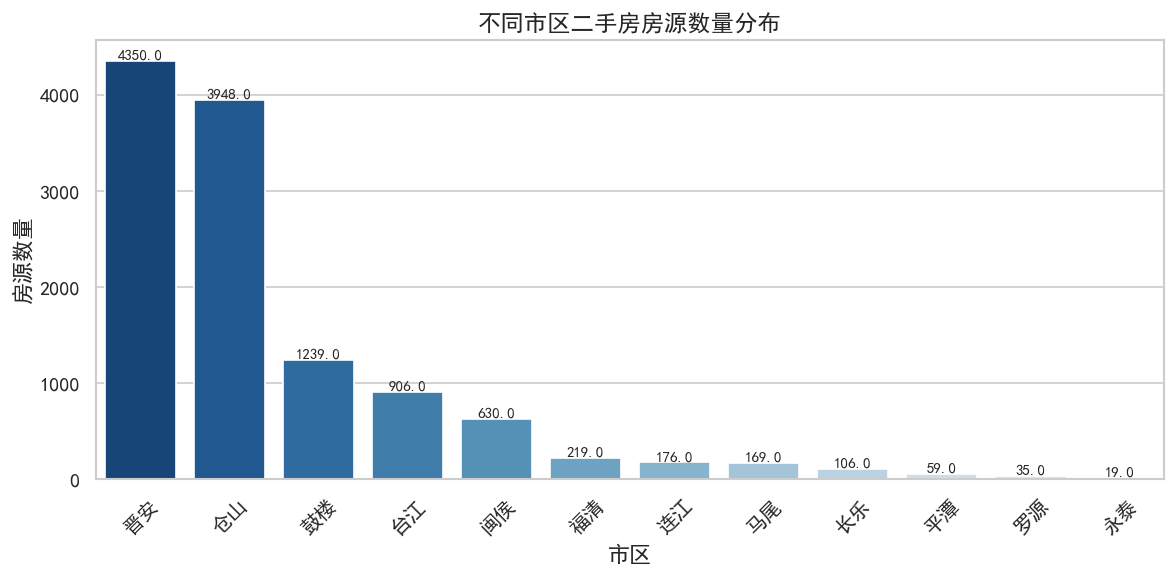

In [ ]:
plt.figure(figsize=(10,5))

order = data['市区'].value_counts().index

ax = sns.countplot(
    data=data,
    x='市区',
    order=order,
    palette='Blues_r'
)

plt.title('不同市区二手房房源数量分布', fontsize=14, fontweight='bold')
plt.xlabel('市区')
plt.ylabel('房源数量')

plt.xticks(rotation=45)


for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

该图展示了不同市区的二手房房源数量分布情况。

可以看出，晋安区、仓山区等区域房源数量明显高于其他区域，说明这些区域是当前二手房市场的主要供应集中地。而如罗源、永泰等区域房源数量较少，市场活跃度相对较低。

整体来看，福州二手房市场呈现出明显的区域集中性，核心城区房源供给更为集中。

### 图表 2：二手房均价分布情况

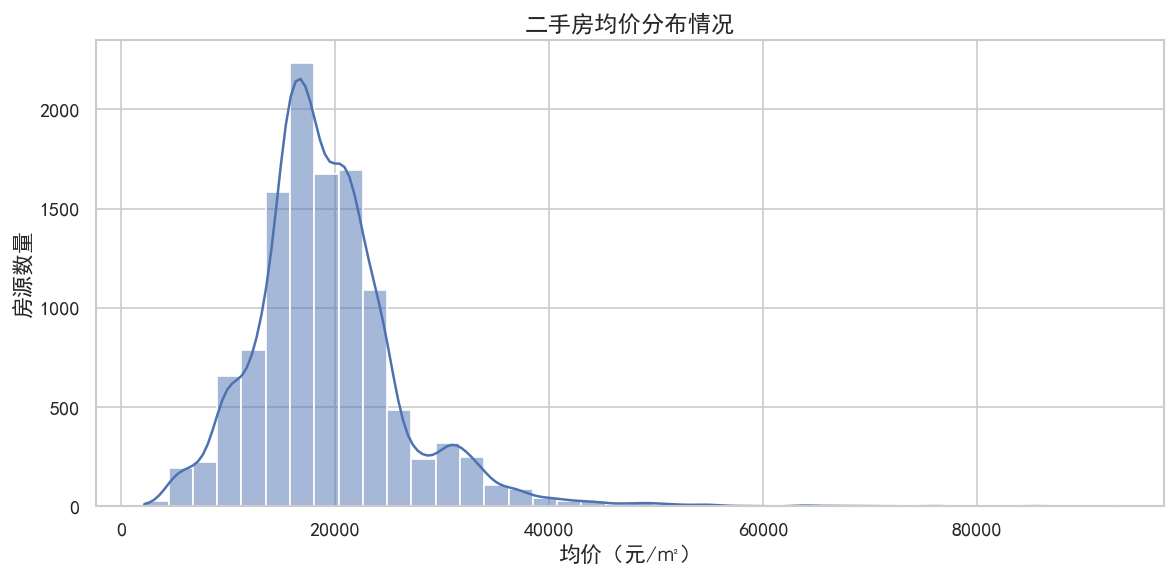

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=data,
    x='均价_元㎡',
    bins=40,
    kde=True,
    color='#4C72B0'
)

plt.title('二手房均价分布情况', fontsize=14, fontweight='bold')
plt.xlabel('均价（元/㎡）')
plt.ylabel('房源数量')

plt.tight_layout()
plt.show()

该图展示了二手房均价的整体分布情况。

可以观察到，房价主要集中在15000–25000元/㎡区间，呈现明显的右偏分布。同时存在少量高价房源（超过40000元/㎡），拉高了整体价格上限。

说明福州二手房市场以中等价位房源为主，但高端房源仍然存在明显溢出效应。

### 图表 3：不同市区房价分布差异

C:\Users\swrx\AppData\Local\Temp\ipykernel_22224\3531465663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


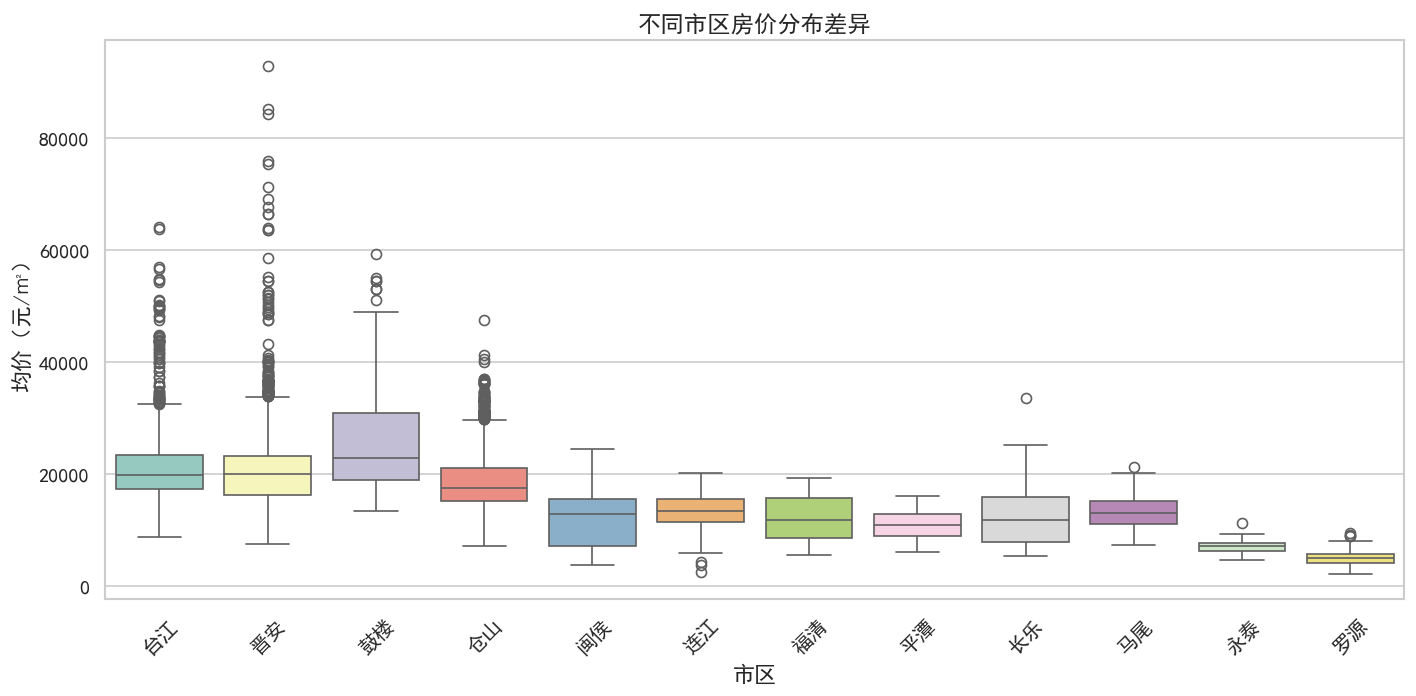

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=data,
    x='市区',
    y='均价_元㎡',
    palette='Set3'
)

plt.title('不同市区房价分布差异', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('均价（元/㎡）')

plt.tight_layout()
plt.show()

该图展示了不同市区的房价分布情况及波动范围。

可以看出，鼓楼区、台江区等核心区域不仅均价较高，而且波动范围较大，存在较多高价离散点。而如罗源、永泰等区域整体房价较低且分布集中。

说明核心区域房价不仅水平高，同时内部差异也较明显。

### 图表 4：房屋面积与总价关系

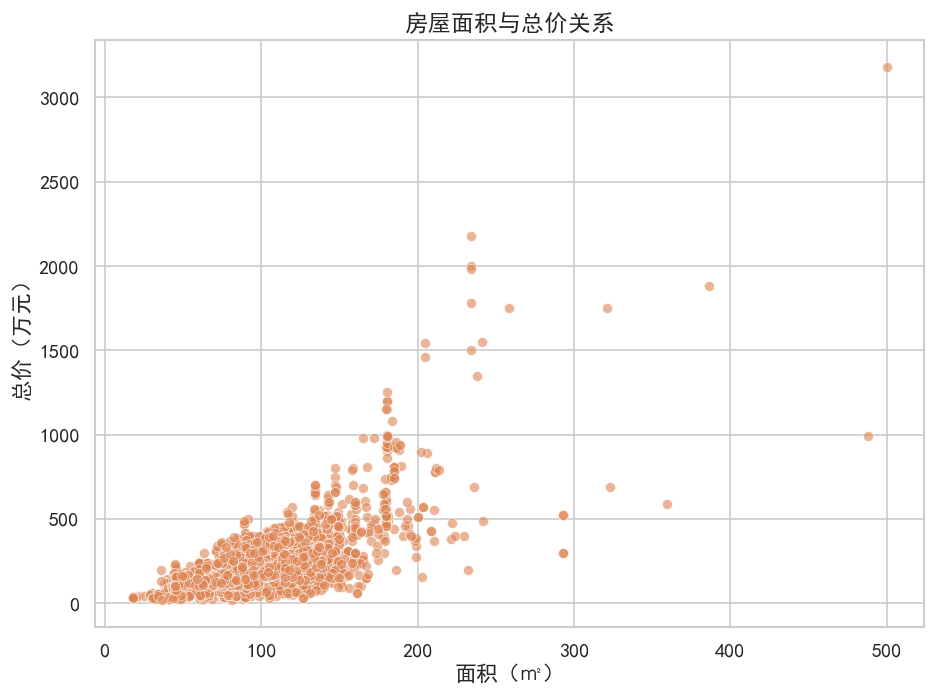

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x='面积_㎡',
    y='总价_万元',
    alpha=0.6,
    color='#DD8452'
)

plt.title('房屋面积与总价关系', fontsize=14, fontweight='bold')
plt.xlabel('面积（㎡）')
plt.ylabel('总价（万元）')

plt.tight_layout()
plt.show()

该图展示了房屋面积与总价之间的关系。

整体呈现明显的正相关趋势，即面积越大，总价越高。但同时可以看到，在相同面积范围内，总价仍存在较大波动，说明房价不仅受面积影响，还受到区域、楼层及房龄等因素共同影响。

### 图5：不同房龄房价变化情况

C:\Users\swrx\AppData\Local\Temp\ipykernel_22224\1814010324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


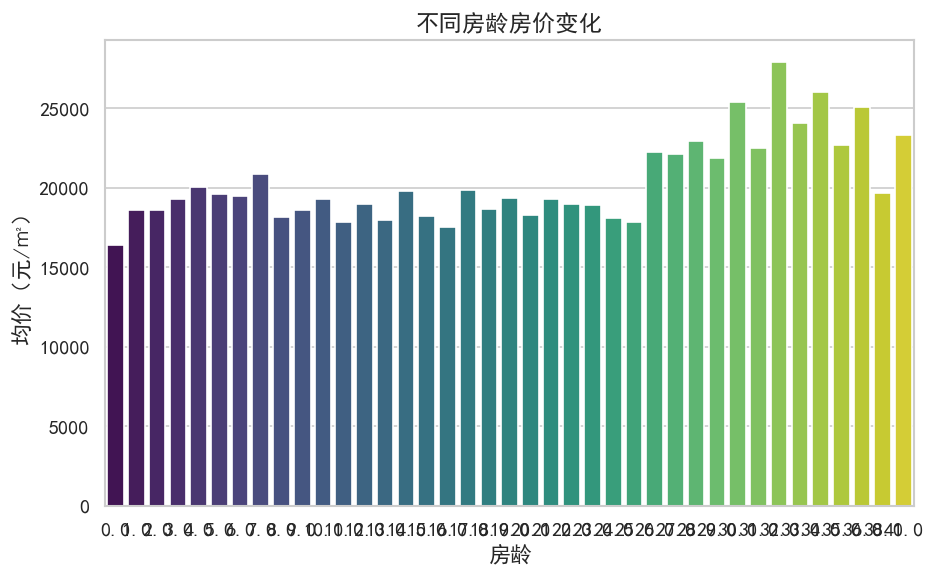

In [ ]:
plt.figure(figsize=(8,5))

age_price = data.groupby('房龄')['均价_元㎡'].mean()

sns.barplot(
    x=age_price.index,
    y=age_price.values,
    palette='viridis'
)

plt.title('不同房龄房价变化', fontsize=14, fontweight='bold')
plt.xlabel('房龄')
plt.ylabel('均价（元/㎡）')

plt.tight_layout()
plt.show()

该图展示了不同房龄房源的平均均价变化情况。

可以看出，较新房源整体均价较高，而随着房龄增加，均价整体呈下降趋势。但在部分区间仍存在波动，说明房龄虽然对房价有影响，但并不是唯一决定因素。

## 8. 主要结论


本次分析基于福州二手房数据，从房源分布、价格水平、空间差异及影响因素等方面进行了系统分析，所有结论均结合前述统计结果与可视化图表得出。


### 1. 房源分布高度集中在核心城区
根据“不同市区二手房房源数量分布图”，晋安区（约4350套）和仓山区（约3948套）明显高于其他区域，而如罗源（35套）和永泰（19套）房源极少，说明房源高度集中在主城区，外围区域市场活跃度较低。



### 2. 房价整体呈右偏分布，中等价格占主导
从“二手房均价分布直方图”可以看出，房价主要集中在15000–25000元/㎡区间，同时存在少量超过40000元/㎡的高价房源，整体呈明显右偏分布结构。



### 3. 不同市区房价差异显著，核心区域价格更高
从“不同市区房价箱线图”可以看出，鼓楼区、台江区等核心区域均价整体明显高于其他区域，同时存在较多高价离散点，说明核心区域不仅价格高，而且内部差异更大。



### 4. 房屋面积与总价呈显著正相关关系
从“面积与总价散点图”可以看出，整体呈明显正相关趋势，即面积越大，总价越高。但在相同面积区间内仍存在较大波动，说明价格还受到区域、楼层等因素影响。


### 5. 房龄对房价存在一定影响，但非决定性因素
从“不同房龄房价变化图”可以看出，较新房源均价整体略高，但不同房龄之间差异并不稳定，说明房龄对价格有影响，但并不是主要决定因素。



## 数据局限性说明

本次分析仍存在以下局限性：

- 部分极端高价或低价房源（如均价超过60000元/㎡或低于5000元/㎡）可能对整体统计结果产生影响；
- 数据可能存在爬取偏差或信息缺失；
- 未纳入学区、交通、地铁等重要变量，因此部分价格差异无法完全解释。

因此，部分结论应结合实际市场环境进一步验证。